In [10]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df_train = pd.read_csv("AppML_InitialProject_train.csv")
df_train = df_train.drop(columns=["p_Truth_Energy"])
df_test = pd. read_csv("AppML_InitialProject_test_classification.csv")

df_train.shape

(180000, 141)

In [12]:
df_train

,averageInteractionsPerCrossing,p_Rhad1,p_Rhad,p_f3,p_weta2,p_Rphi,p_Reta,p_Eratio,p_f1,p_TRTPID,...,pX_E7x11_Lr1,pX_E7x11_Lr2,pX_E7x11_Lr3,pX_E7x7_Lr0,pX_E7x7_Lr1,p_pt_track,p_eta,p_phi,p_charge,p_Truth_isElectron
0,55.50,-0.002390,-0.003614,0.000744,0.010088,0.947685,0.983722,0.969448,0.355275,-0.030026,...,16208.0300,27951.328,473.046360,1415.2955,16208.0300,38339.8750,0.725108,2.511338,-1.0,1
1,33.50,-0.009279,-0.010666,0.003784,0.011625,0.922366,0.955934,0.918366,0.397633,0.335419,...,28639.7420,34642.820,86.462740,11456.5240,28639.7420,26470.8900,1.566765,-0.593568,-1.0,1
2,35.50,0.002806,0.013643,0.025505,0.010330,0.969845,0.945576,0.921568,0.077971,0.517517,...,8061.6840,88892.890,2173.160200,0.0000,8061.6840,32989.9570,1.926261,2.497809,-1.0,1
3,40.49,-0.001910,0.000044,0.000176,0.010323,0.923816,0.888029,0.000000,0.000000,0.133801,...,27257.8890,39768.450,102.033676,35418.3050,27154.4340,86615.2340,1.510641,2.441266,-1.0,1
4,52.50,0.013779,-0.002106,0.010156,0.010096,0.899883,0.717177,0.782584,0.253658,-0.044038,...,6206.0938,15531.818,277.199130,1242.5723,6206.0938,17362.5060,-0.113342,3.003595,-1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179995,48.50,0.664485,0.785885,0.030614,0.013458,0.706411,0.803551,0.176808,0.310948,0.090996,...,9420.7740,19028.691,1456.618000,2519.9902,9452.5410,21610.8260,-0.333357,2.638398,1.0,0
179996,45.49,0.626207,0.890136,0.002500,0.011333,0.933887,0.870006,0.887657,0.288254,-0.153530,...,7939.0913,14750.185,995.310060,3643.7200,7939.0913,19252.5310,-1.206471,-1.202972,1.0,0
179997,49.50,0.068849,0.099816,0.017091,0.013220,0.777033,0.898677,0.127255,0.378862,-0.000000,...,22392.7870,48182.340,697.059200,0.0000,22392.7870,3583.9360,2.352615,-2.420230,-1.0,0
179998,39.49,0.688895,1.168897,0.009258,0.012657,0.503309,0.734173,0.092843,0.412541,-0.320695,...,20544.4140,26506.123,976.097800,8783.8370,20544.4140,7410.3380,-1.650526,-1.739836,-1.0,0


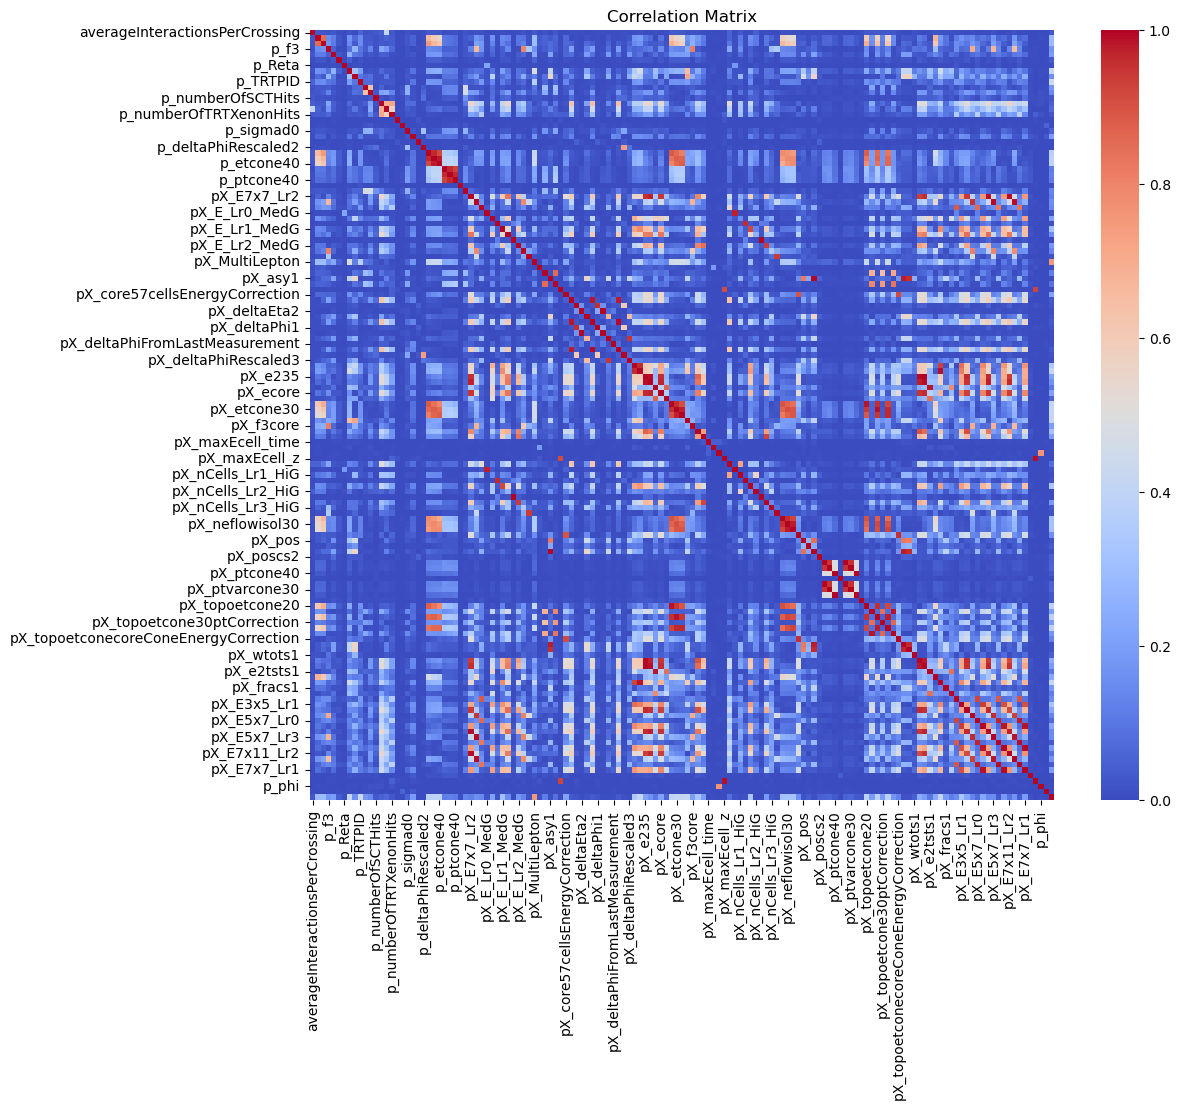

In [13]:
corr = df_train.corr().abs()

# Plot
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr,
    cmap='coolwarm',
    vmin=0,
    vmax=1,
    linewidths=0
)


plt.title("Correlation Matrix")
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score
import shap
from sklearn.metrics import confusion_matrix

In [15]:
X = df_train.drop(columns=["p_Truth_isElectron"])
y = df_train["p_Truth_isElectron"]

In [16]:
# split the data
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
) 

In [17]:
# Train a BDT on all the feautures
model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

AUC = 0.9945628698597913


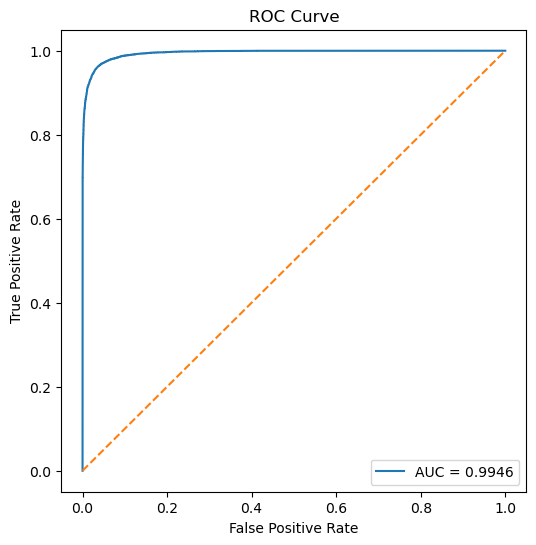

In [18]:
# Evalute the Model
scores = model.predict_proba(X_valid)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, scores)

roc_auc = auc(fpr, tpr)

print("AUC =", roc_auc)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

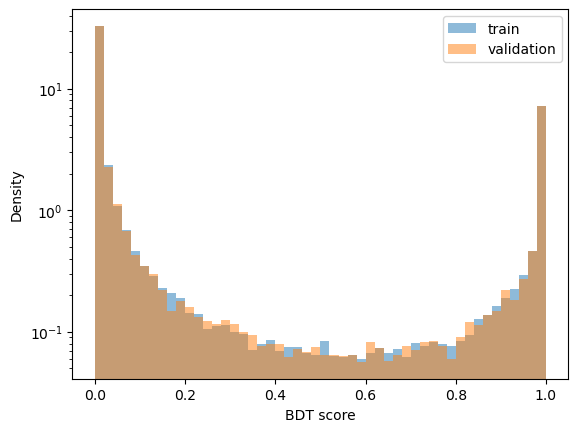

In [19]:
train_scores = model.predict_proba(X_train)[:,1]
valid_scores = model.predict_proba(X_valid)[:,1]

plt.hist(
    train_scores,
    bins=50,
    density=True,
    alpha=0.5,
    label="train"
)

plt.hist(
    valid_scores,
    bins=50,
    density=True,
    alpha=0.5,
    label="validation"
)

plt.xlabel("BDT score")
plt.ylabel("Density")
plt.legend()
plt.yscale("log")

plt.show()

In [20]:
# Find the feauture importance
importance = model.feature_importances_

feat_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importance
})

feat_importance = feat_importance.sort_values(
    by="importance",
    ascending=False
)

print(feat_importance.head(15))

                                   feature  importance
42                          pX_MultiLepton    0.433135
22                              p_etcone20    0.155370
10            p_numberOfInnermostPixelHits    0.084854
23                              p_etcone30    0.030117
18                               p_sigmad0    0.014102
111  pX_topoetconecoreConeEnergyCorrection    0.012141
9                                 p_TRTPID    0.012068
28                                p_ptPU30    0.012060
92   pX_neflowisolcoreConeEnergyCorrection    0.010905
7                                 p_Eratio    0.010842
20                             p_deltaEta1    0.008031
2                                   p_Rhad    0.007641
44                        pX_ambiguityType    0.007594
46                               pX_author    0.007105
50                            pX_deltaEta1    0.006942


In [21]:
# Extract the 15 most important features
top15 = feat_importance.head(15)["feature"].tolist()

X_train_top = X_train[top15]
X_valid_top = X_valid[top15]

In [22]:
# Train a BDT on the 15 most important feautures
bdt = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    random_state=42
)

bdt.fit(
    X_train_top,
    y_train,
    eval_set=[(X_train_top, y_train),
              (X_valid_top, y_valid)],
    verbose=True
)

[0]	validation_0-auc:0.96505	validation_1-auc:0.96451
[1]	validation_0-auc:0.97174	validation_1-auc:0.97101
[2]	validation_0-auc:0.97197	validation_1-auc:0.97123
[3]	validation_0-auc:0.97292	validation_1-auc:0.97225
[4]	validation_0-auc:0.97637	validation_1-auc:0.97556
[5]	validation_0-auc:0.97619	validation_1-auc:0.97537
[6]	validation_0-auc:0.97604	validation_1-auc:0.97520
[7]	validation_0-auc:0.97591	validation_1-auc:0.97506
[8]	validation_0-auc:0.97602	validation_1-auc:0.97511
[9]	validation_0-auc:0.97627	validation_1-auc:0.97525
[10]	validation_0-auc:0.97622	validation_1-auc:0.97520
[11]	validation_0-auc:0.97651	validation_1-auc:0.97570
[12]	validation_0-auc:0.97655	validation_1-auc:0.97577
[13]	validation_0-auc:0.97661	validation_1-auc:0.97582
[14]	validation_0-auc:0.97687	validation_1-auc:0.97604
[15]	validation_0-auc:0.97684	validation_1-auc:0.97603
[16]	validation_0-auc:0.97686	validation_1-auc:0.97607
[17]	validation_0-auc:0.97724	validation_1-auc:0.97641
[18]	validation_0-au

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.03, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=500,
              n_jobs=None, num_parallel_tree=None, ...)

AUC = 0.9906238387942562


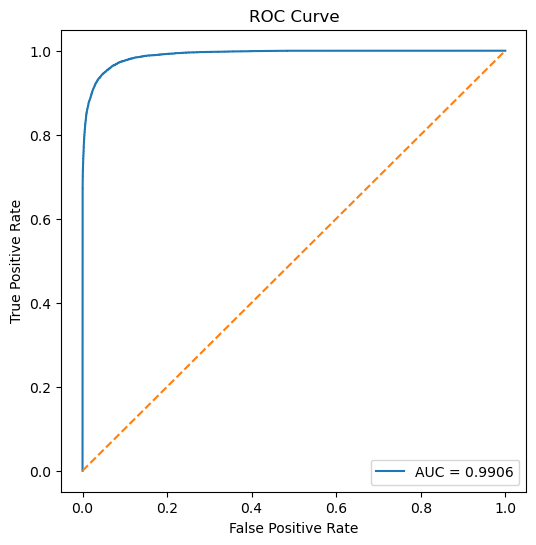

In [23]:
# Evalute the Model
scores = bdt.predict_proba(X_valid_top)[:, 1]

fpr, tpr, thresholds = roc_curve(y_valid, scores)

roc_auc = auc(fpr, tpr)

print("AUC =", roc_auc)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

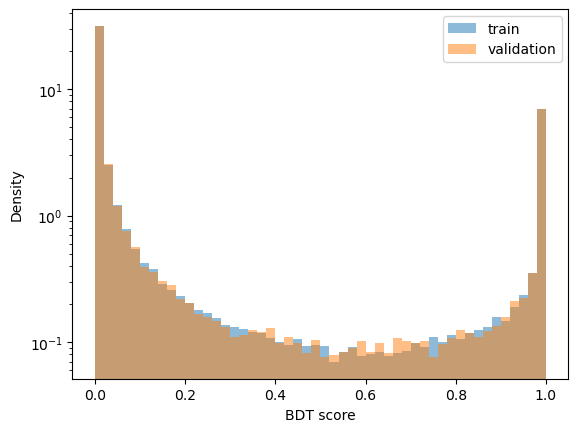

In [24]:
# Check for Overtraining
train_scores = bdt.predict_proba(X_train_top)[:,1]
valid_scores = bdt.predict_proba(X_valid_top)[:,1]

plt.hist(
    train_scores,
    bins=50,
    density=True,
    alpha=0.5,
    label="train"
)

plt.hist(
    valid_scores,
    bins=50,
    density=True,
    alpha=0.5,
    label="validation"
)

plt.xlabel("BDT score")
plt.ylabel("Density")
plt.yscale("log")
plt.legend()

plt.show()

In [25]:
# Cross-Validation scores
cv_scores = cross_val_score(
    bdt,
    X[top15],
    y,
    cv=5,
    scoring="roc_auc"
)

print(cv_scores.mean())

0.9908147780717226


In [26]:
preds = (scores > 0.5).astype(int)

cm = confusion_matrix(y_valid, preds)

print(cm)

[[41961   699]
 [ 1343  9997]]


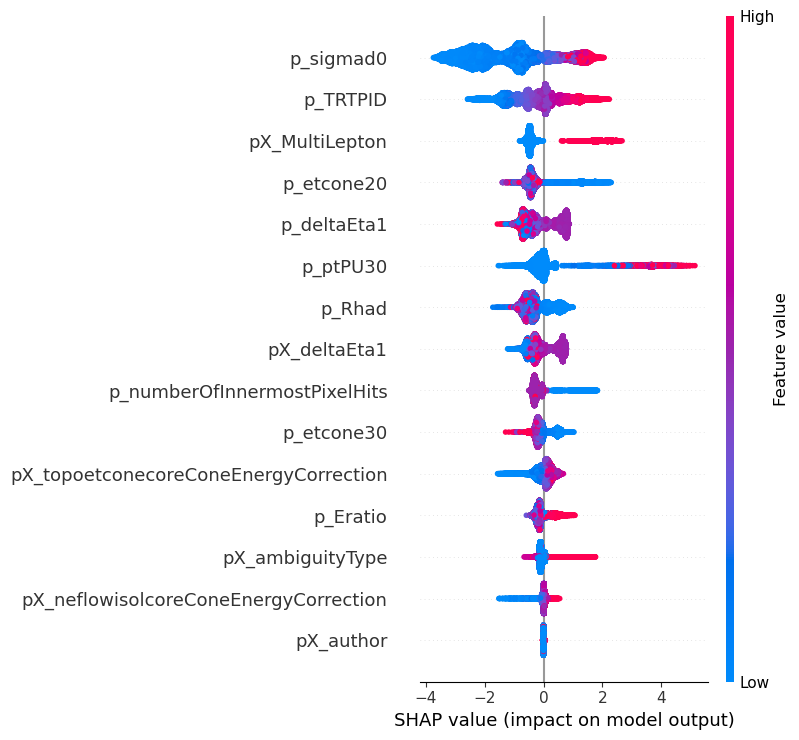

In [27]:
explainer = shap.TreeExplainer(bdt)

shap_values = explainer.shap_values(X_valid_top)

shap.summary_plot(shap_values, X_valid_top)

In [30]:
from bayes_opt import BayesianOptimization
from sklearn.metrics import roc_auc_score

In [31]:
def xgb_auc(
    max_depth,
    learning_rate,
    n_estimators,
    subsample,
    colsample_bytree,
    min_child_weight,
    gamma,
    reg_alpha,
    reg_lambda
):

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="auc",
        random_state=42,
        tree_method="hist",

        # Parameters to optimize
        max_depth=int(max_depth),
        learning_rate=learning_rate,
        n_estimators=int(n_estimators),
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        min_child_weight=min_child_weight,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda
    )

    # Cross-validation AUC
    scores = cross_val_score(
        model,
        X_train_top,
        y_train,
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    return scores.mean()


# =========================================================
# Search Space
# =========================================================
pbounds = {
    "max_depth": (3, 10),
    "learning_rate": (0.01, 0.3),
    "n_estimators": (100, 1000),
    "subsample": (0.5, 1.0),
    "colsample_bytree": (0.5, 1.0),
    "min_child_weight": (1, 10),
    "gamma": (0, 5),
    "reg_alpha": (0, 5),
    "reg_lambda": (0, 5),
}


# =========================================================
# Optimizer
# =========================================================
optimizer = BayesianOptimization(
    f=xgb_auc,
    pbounds=pbounds,
    random_state=42,
    verbose=2
)


# =========================================================
# Run Optimization
# =========================================================
optimizer.maximize(
    init_points=10,   # random exploration
    n_iter=40         # Bayesian optimization steps
)


# =========================================================
# Best Parameters
# =========================================================
print("\nBest Result:")
print(optimizer.max)

best_params = optimizer.max["params"]

# Convert integer params
best_params["max_depth"] = int(best_params["max_depth"])
best_params["n_estimators"] = int(best_params["n_estimators"])


# =========================================================
# Train Final Model
# =========================================================
best_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    tree_method="hist",
    **best_params
)

best_model.fit(
    X_train_top,
    y_train,
    eval_set=[
        (X_train_top, y_train),
        (X_valid_top, y_valid)
    ],
    verbose=True
)

# =========================================================
# Validation AUC
# =========================================================
y_pred_proba = best_model.predict_proba(X_valid_top)[:, 1]

auc = roc_auc_score(y_valid, y_pred_proba)

print(f"\nValidation AUC: {auc:.5f}")

|   iter    |  target   | max_depth | learni... | n_esti... | subsample | colsam... | min_ch... |   gamma   | reg_alpha | reg_la... |
-------------------------------------------------------------------------------------------------------------------------------------


/home/jona/micromamba/envs/appmlenv/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/jona/micromamba/envs/appmlenv/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux201

| 1         | 0.9894820 | 5.6217808 | 0.2857071 | 758.79454 | 0.7993292 | 0.5780093 | 2.4039506 | 0.2904180 | 4.3308807 | 3.0055750 |


/home/jona/micromamba/envs/appmlenv/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/home/jona/micromamba/envs/appmlenv/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux201

| 2         | 0.9911018 | 7.9565080 | 0.0159695 | 972.91886 | 0.9162213 | 0.6061695 | 2.6364247 | 0.9170225 | 1.5212112 | 2.6237821 |
| 3         | 0.9909978 | 6.0236151 | 0.0944564 | 650.66760 | 0.5697469 | 0.6460723 | 4.2972565 | 2.2803499 | 3.9258798 | 0.9983689 |
| 4         | 0.9906389 | 6.5996410 | 0.1818002 | 141.80537 | 0.8037724 | 0.5852620 | 1.5854643 | 4.7444276 | 4.8281601 | 4.0419867 |
| 5         | 0.9910483 | 5.1322963 | 0.0383249 | 715.80972 | 0.7200762 | 0.5610191 | 5.4565921 | 0.1719426 | 4.5466020 | 1.2938999 |
| 6         | 0.9908217 | 7.6376559 | 0.1003962 | 568.06121 | 0.7733551 | 0.5924272 | 9.7262616 | 3.8756641 | 4.6974947 | 4.4741367 |
| 7         | 0.9902767 | 7.1852998 | 0.2773435 | 179.64325 | 0.5979914 | 0.5226136 | 3.9279729 | 1.9433864 | 1.3567451 | 4.1436875 |
| 8         | 0.9908011 | 5.4972732 | 0.0914710 | 588.42647 | 0.5704621 | 0.9010984 | 1.6709557 | 4.9344346 | 3.8612238 | 0.9935784 |
| 9         | 0.9907471 | 3.0386548 | 0.2464838 | 736.17160 | 

In [33]:
best_params = optimizer.max["params"]

# Convert integer parameters
best_params["max_depth"] = int(best_params["max_depth"])
best_params["n_estimators"] = int(best_params["n_estimators"])

print(best_params)

{'max_depth': 7, 'learning_rate': np.float64(0.01596950334578271), 'n_estimators': 972, 'subsample': np.float64(0.9162213204002109), 'colsample_bytree': np.float64(0.6061695553391381), 'min_child_weight': np.float64(2.636424704863906), 'gamma': np.float64(0.9170225492671691), 'reg_alpha': np.float64(1.5212112147976886), 'reg_lambda': np.float64(2.6237821581611893)}


In [34]:
df_test = pd. read_csv("AppML_InitialProject_test_classification.csv")

X_test = df_test

top15 = feat_importance.head(15)["feature"].tolist()

X_unlabeled_top = X_test[top15]

In [35]:
# =========================================================
# Train final model using optimized parameters
# =========================================================

final_model = XGBClassifier(
    **best_params
)

final_model.fit(
    X_train_top,
    y_train
)

# =========================================================
# Predict on unlabeled data
# =========================================================

# Probability predictions
unlabeled_probs = final_model.predict_proba(X_unlabeled_top)[:, 1]

# Binary class predictions
unlabeled_preds = final_model.predict(X_unlabeled_top)

# =========================================================
# Save predictions
# =========================================================

results = pd.DataFrame({
    "prediction": unlabeled_preds,
    "probability": unlabeled_probs
})

print(results.head())

   prediction  probability
0           1     0.998684
1           1     0.786959
2           0     0.172259
3           1     0.999644
4           1     0.944826


In [38]:
results.to_csv("classification_XGB_rough.csv", index = False)